In [1]:
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

In [18]:
BATCH_SIZE=512

## Data Loading

In [14]:
from datasets import load_dataset
ds = load_dataset("zh-plus/tiny-imagenet")

## Data Preprocessing
### Data Augmentation

In [13]:
transform = transforms.Compose(
    [
        transforms.RandomCrop(size=56),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        # ADD FancyPCA
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]
)

In [19]:
dataloader = DataLoader(
        ds,
        shuffle=True,
        pin_memory=True,
        num_workers=8,
        drop_last=True,
        batch_size=BATCH_SIZE)

### Model


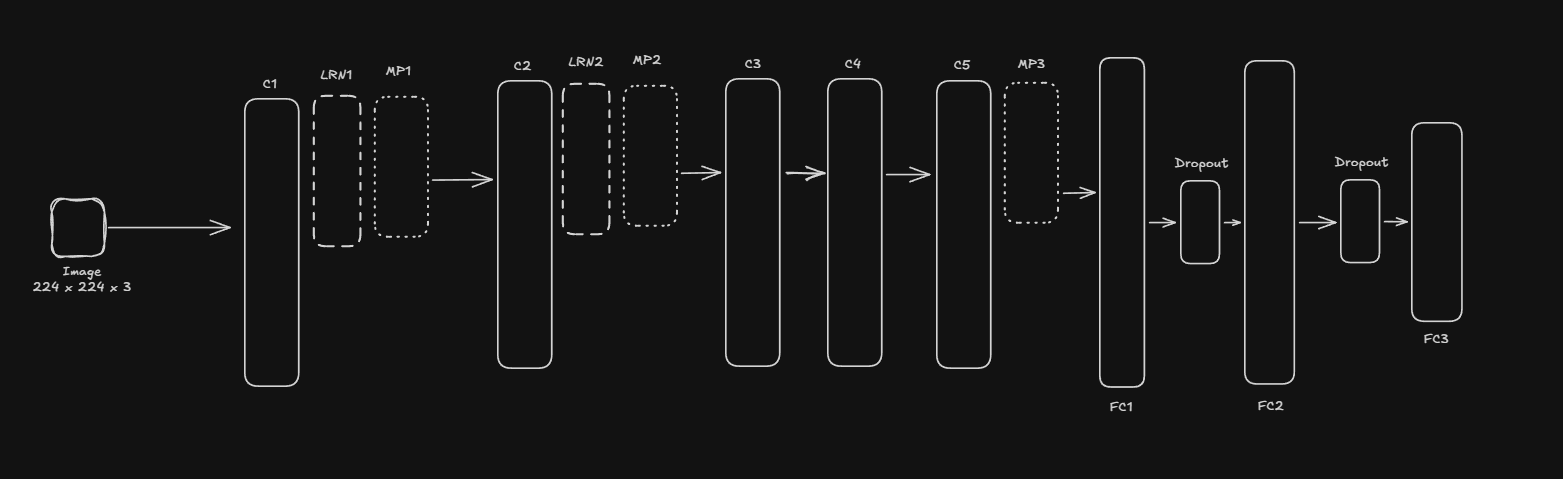


In [ ]:
class AlexNet(nn.Module):
    def __init__(self,num_classes):
        super().__init__()

        self.lrn = nn.LocalResponseNorm(size=5, alpha=0.0004, beta=0.75, k=2)
        self.mp = nn.MaxPool2d(stride=2,kernel_size=3)

        self.c1 = nn.Conv2d(in_channels=3,out_channels=96,stride=4,kernel_size=11) 
        self.c2 = nn.Conv2d(in_channels=96, out_channels=256,kernel_size=5)
        self.c3 = nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3)
        self.c4 = nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3)
        self.c5 = nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3)

        self.fc1 = nn.Linear(in_features=1728, out_features=4096)
        self.fc2 = nn.Linear(in_features=4096,  out_features=4096)
        self.fc3 = nn.Linear(in_features=4096,  out_features=num_classes)


    def forward(self,x):
        # Layer 1
        x = self.c1(x)
        x = F.ReLU(x)
        x = self.lrn(x)
        x = self.mp(x)

        # Layer 2
        x = self.c2(x)
        x = F.ReLU(x)
        x = self.lrn(x)
        x = self.mp(x)

        # Layer 3
        x = self.c3(x)
        x = F.ReLU(x)

        # Layer 4
        x = self.c4(x)
        x = F.ReLU(x)

        # Layer 5
        x = self.c5(x)
        x = F.ReLU(x)
        x = self.mp(x)


        ## Classifier

        x = nn.Flatten(x)

        # Layer 6
        x = self.fc1(x)
        x = F.Dropout(x,p=0.5)

        # Layer 7
        x = self.fc2(x)
        x = F.Dropout(x,p=0.5)

        # Layer 8
        x = self.fc3(x)